In [69]:
from sklearn.neighbors import KNeighborsClassifier

In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/drive/MyDrive/Heart Disease Cleveland UCI/heart_cleveland_upload.csv")

X = df.drop("condition", axis=1)
y = df["condition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [71]:
# Display Dataset

display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [72]:
# Model Initialization

knn = KNeighborsClassifier(
    n_neighbors=5
)

In [73]:
# Model Training

start_train = time.time()

knn.fit(X_train, y_train)

train_time = time.time() - start_train

In [74]:
# Prediction

start_test = time.time()

y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]

test_time = time.time() - start_test

In [75]:
# Performance Metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

balanced_acc = balanced_accuracy_score(y_test, y_pred)

mcc = matthews_corrcoef(y_test, y_pred)

kappa = cohen_kappa_score(y_test, y_pred)

loss = log_loss(y_test, y_prob)

cv_scores = cross_val_score(
    knn,
    X_train,
    y_train,
    cv=10,
    scoring="accuracy"
)

cv_mean = cv_scores.mean()

cv_std = cv_scores.std()

In [76]:
# Print Performance

print("K-Nearest Neighbors Performance\n")

print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1 Score            : {f1:.4f}")
print(f"ROC-AUC             : {roc_auc:.4f}")
print(f"Balanced Accuracy   : {balanced_acc:.4f}")
print(f"Matthews CC         : {mcc:.4f}")
print(f"Cohen's Kappa       : {kappa:.4f}")
print(f"Log Loss            : {loss:.4f}")

print(f"\nCV Mean Accuracy    : {cv_mean:.4f}")
print(f"CV Std              : {cv_std:.4f}")

print(f"\nTraining Time       : {train_time:.4f} sec")
print(f"Prediction Time     : {test_time:.4f} sec")

K-Nearest Neighbors Performance

Accuracy            : 0.9000
Precision           : 1.0000
Recall              : 0.7857
F1 Score            : 0.8800
ROC-AUC             : 0.9593
Balanced Accuracy   : 0.8929
Matthews CC         : 0.8134
Cohen's Kappa       : 0.7964
Log Loss            : 0.8246

CV Mean Accuracy    : 0.7893
CV Std              : 0.0609

Training Time       : 0.0070 sec
Prediction Time     : 0.0126 sec


In [77]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91        32
           1       1.00      0.79      0.88        28

    accuracy                           0.90        60
   macro avg       0.92      0.89      0.90        60
weighted avg       0.92      0.90      0.90        60



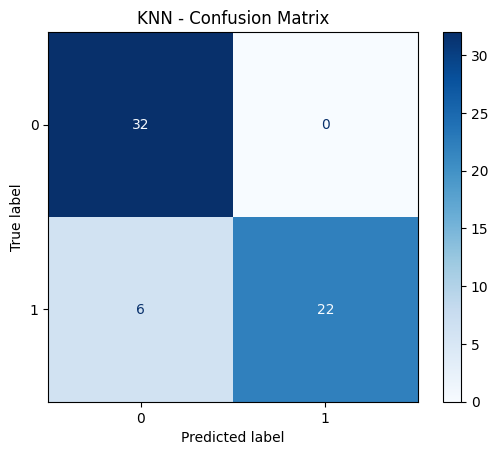

In [78]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("KNN - Confusion Matrix")
plt.show()

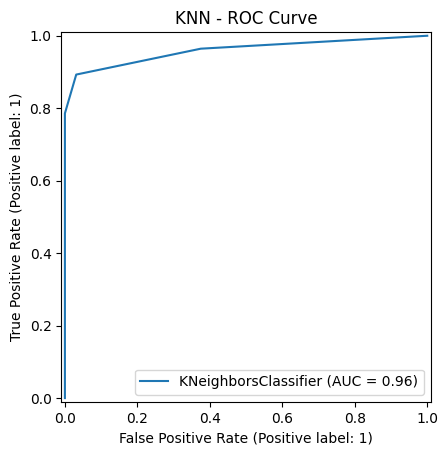

In [79]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# ROC Curve

RocCurveDisplay.from_estimator(
    knn,
    X_test,
    y_test
)

plt.title("KNN - ROC Curve")
plt.show()

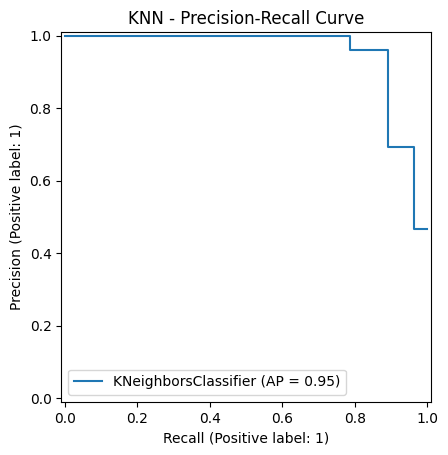

In [80]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Precision-Recall Curve

PrecisionRecallDisplay.from_estimator(
    knn,
    X_test,
    y_test
)

plt.title("KNN - Precision-Recall Curve")
plt.show()

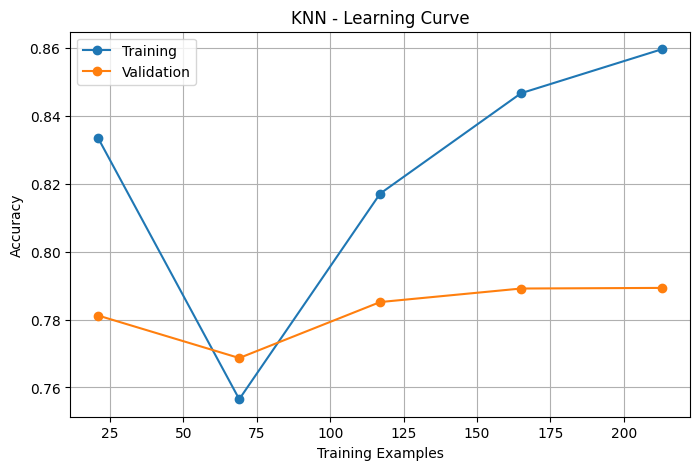

In [81]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

# Learning Curve

train_sizes, train_scores, test_scores = learning_curve(
    knn,
    X_train,
    y_train,
    cv=10,
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker="o", label="Training")

plt.plot(train_sizes, test_mean, marker="o", label="Validation")

plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("KNN - Learning Curve")

plt.legend()
plt.grid(True)

plt.show()

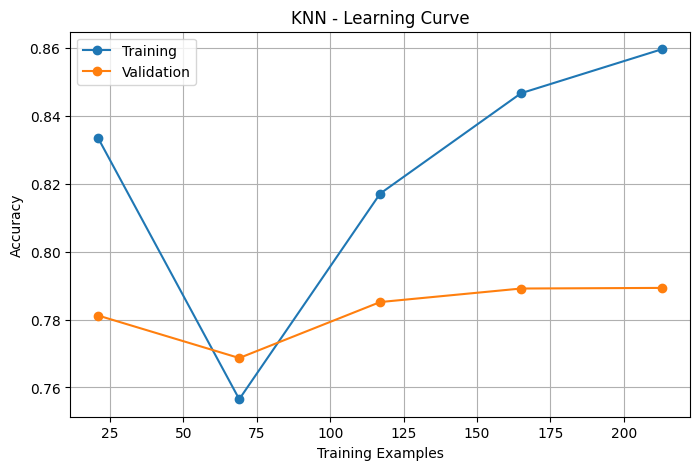

In [82]:
# Learning Curve

train_sizes, train_scores, test_scores = learning_curve(
    knn,
    X_train,
    y_train,
    cv=10,
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker="o", label="Training")

plt.plot(train_sizes, test_mean, marker="o", label="Validation")

plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("KNN - Learning Curve")

plt.legend()
plt.grid(True)

plt.show()

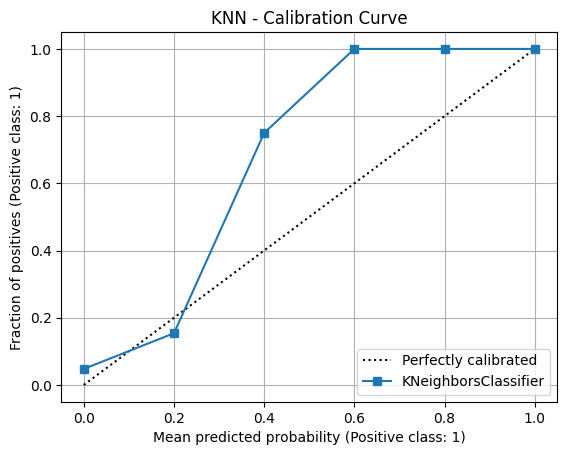

In [84]:
# Calibration Curve

from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(
    knn,
    X_test,
    y_test,
    n_bins=10
)

plt.title("KNN - Calibration Curve")
plt.grid(True)
plt.show()

In [83]:
# Save Results

knn_results = {
    "Model": "K-Nearest Neighbors",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc,
    "Balanced_Accuracy": balanced_acc,
    "MCC": mcc,
    "Kappa": kappa,
    "Log_Loss": loss,
    "CV_Mean": cv_mean,
    "CV_STD": cv_std,
    "Train_Time": train_time,
    "Predict_Time": test_time
}